## **LOGISTIC REGRESSION**

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Exploration:

In [2]:
# Load the dataset
train_df = pd.read_csv('Titanic_train.csv')
test_df = pd.read_csv('Titanic_test.csv')

In [3]:
# Display first few rows 
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Basic dataset information
print("Training data shape:") 
train_df.shape
print("\nColumn info:")
train_df.info()

Training data shape:

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Summary statistics
train_df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
# Visualizations for EDA

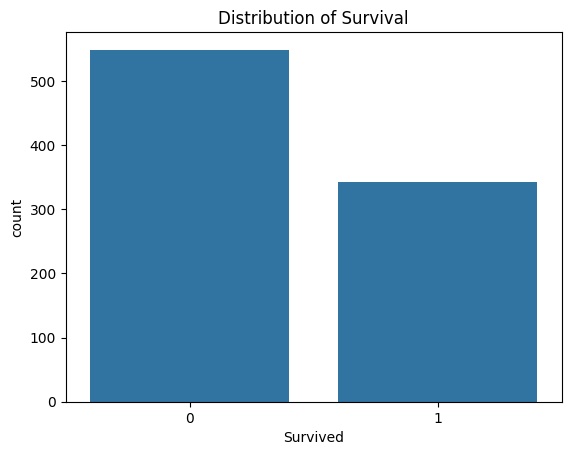

In [7]:
# Distribution of target variable
sns.countplot(data=train_df, x='Survived')
plt.title("Distribution of Survival")  # Title for plot
plt.show()   # Display the plot

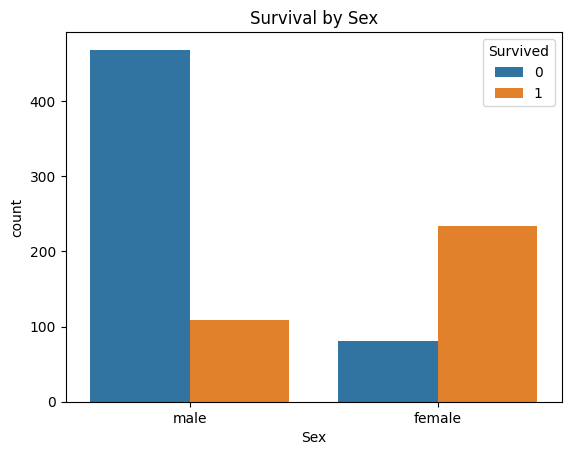

In [8]:
# Sex vs Survival
sns.countplot(data=train_df, x='Sex', hue='Survived')
plt.title("Survival by Sex") 
plt.show()

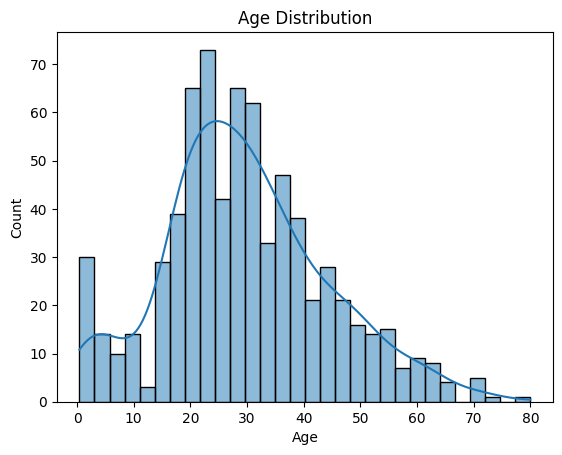

In [9]:
# Age distribution
sns.histplot(train_df['Age'].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

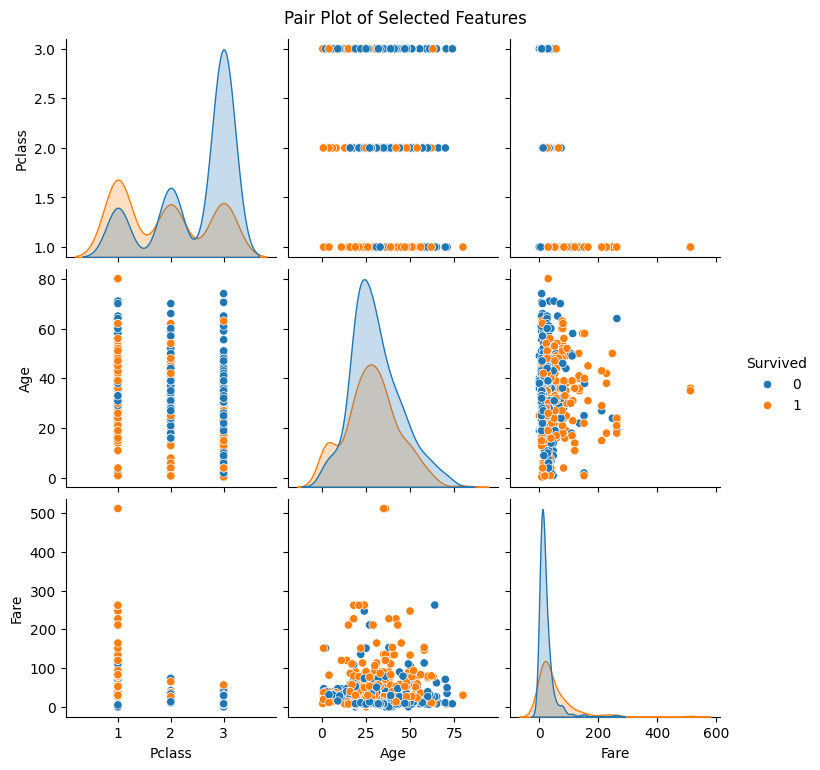

In [10]:
# Pair plot with selected numerical features
sns.pairplot(train_df[['Survived', 'Pclass', 'Age', 'Fare']].dropna(), hue='Survived') # Plot peri plot
plt.suptitle("Pair Plot of Selected Features", y=1.02)  # Title for plot
plt.show()  # Display the plot

In [11]:
# Drop non-numeric columns before correlation analysis
numeric_df = train_df.select_dtypes(include=[np.number])

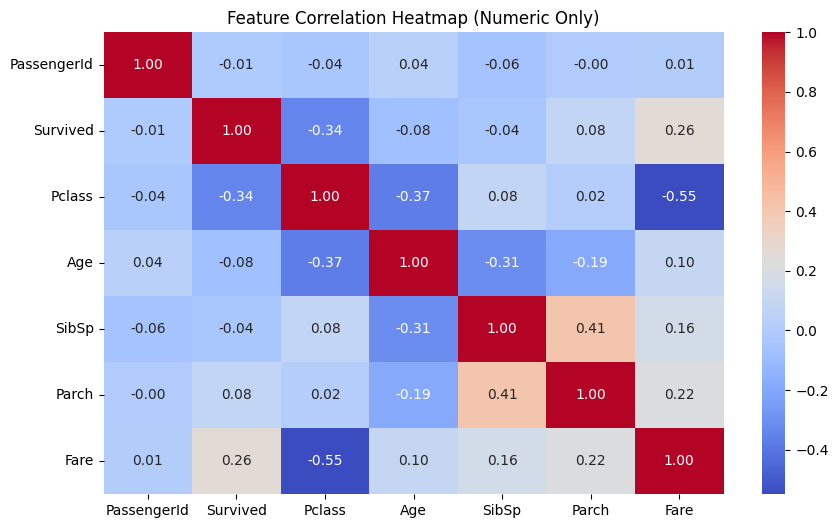

In [12]:
# Plot correlation heatmap only on numeric data
plt.figure(figsize=(10, 6)) # Set figure size
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")  # Plot the heatmap
plt.title("Feature Correlation Heatmap (Numeric Only)")  # Title for the plot
plt.show()    # Display the plot

## 2. Data Preprocessing:

In [13]:
#Handling missing values
# Fill missing Age values with median
train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
test_df['Age'].fillna(test_df['Age'].median(), inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_4692\3053941695.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Age'].fillna(train_df['Age'].median(), inplace=True)
C:\Users\harsh\AppData\Local\Temp\ipykernel_4692\3053941695.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a co

In [14]:
# Fill missing Embarked values with the most frequent value
train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
test_df['Embarked'].fillna(test_df['Embarked'].mode()[0], inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_4692\516368245.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['Embarked'].fillna(train_df['Embarked'].mode()[0], inplace=True)
C:\Users\harsh\AppData\Local\Temp\ipykernel_4692\516368245.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [15]:
# Fill missing Fare in test data
test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)

C:\Users\harsh\AppData\Local\Temp\ipykernel_4692\462745118.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_df['Fare'].fillna(test_df['Fare'].median(), inplace=True)


In [16]:
# Drop 'Cabin' due to too many missing values
train_df.drop('Cabin', axis=1, inplace=True)
test_df.drop('Cabin', axis=1, inplace=True)

In [17]:
#Encoding categorical variables

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [19]:
# Convert categorical columns to numeric using Label Encoding
label_enc = LabelEncoder()
for col in ['Sex', 'Embarked']:
    train_df[col] = label_enc.fit_transform(train_df[col])
    test_df[col] = label_enc.transform(test_df[col])

In [20]:
# Drop unnecessary columns
drop_cols = ['PassengerId', 'Name', 'Ticket']
test_ids = test_df['PassengerId']   # Save IDs for submission or prediction
train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

In [21]:
# Separate features and target
X = train_df.drop('Survived', axis=1)
y = train_df['Survived']

In [22]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_df)

In [23]:
# Split training data for validation
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## 3. Model Building:

In [24]:
#Build logistic regression model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

## 4. Model Evaluation:

In [25]:
# Predictions
y_pred = log_model.predict(X_val)
y_prob = log_model.predict_proba(X_val)[:, 1]

In [26]:
# Classification metrics
print("Classification Report:\n", classification_report(y_val, y_pred)) # Show Classification Report
print("Confusion Matrix:\n", confusion_matrix(y_val, y_pred))           # Show Confusion Matrix
print("ROC AUC Score:", roc_auc_score(y_val, y_prob))                   # Show ROC AUC Score

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
 [[90 15]
 [20 54]]
ROC AUC Score: 0.8818532818532818


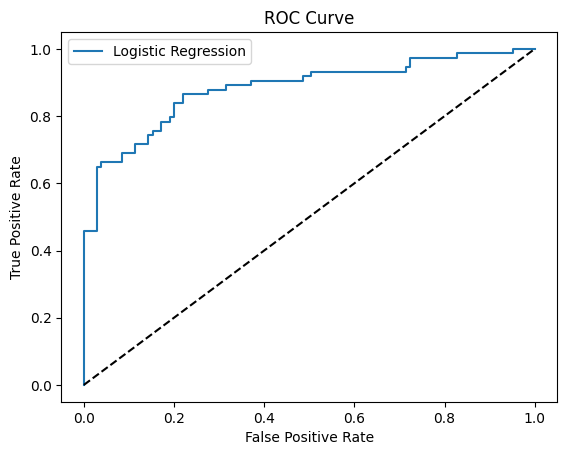

In [27]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)  # Compute false positive rate, true positive rate, and thresholds
plt.plot(fpr, tpr, label='Logistic Regression')  # Plot the ROC curve
plt.plot([0, 1], [0, 1], 'k--')                  # Plot the diagonal reference line 
plt.xlabel('False Positive Rate') # x-axis label
plt.ylabel('True Positive Rate')  # y-axis label
plt.title('ROC Curve')  # Title for the plot
plt.legend()   # Show Labels
plt.show()     # Display the plot

## 5. Interpretation:

In [28]:
# Coefficients and their impact
coef_df = pd.DataFrame({
    'Feature': X.columns,              # Assign feature names
    'Coefficient': log_model.coef_[0]  # Assign corresponding coefficients from the trained model
})

# Sort the features by the strength of their coefficients
coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
5,Fare,0.121214
4,Parch,-0.100018
6,Embarked,-0.174770
3,SibSp,-0.328189
2,Age,-0.395757
0,Pclass,-0.792517
1,Sex,-1.285813


### Discuss the significance of features in predicting the target variable (survival probability in this case).
##### Following Features Help Predict Survival:
##### 1.Sex:
###### One of the most significant predictors of survival.
###### Women had a much higher survival rate due to the "women and children first" evacuation policy.
##### 2.Fare:
###### Passengers who paid higher fares were more likely to survive.
###### Indicates higher social class and possibly better access to lifeboats.
##### 3.Pclass (Passenger Class)
###### Passengers in lower classes (especially 3rd class) had lower survival rates.
###### First-class passengers generally had the highest survival chances.
##### 4.Age:
###### Younger passengers, especially children, had better chances of survival.
###### Age can vary in influence, but very old or very young people might be more vulnerable.
##### 5.SibSp (Siblings/Spouses Aboard) and Parch (Parents/Children Aboard):
###### These features reflect family presence on board.
###### Having family members around could increase chances of survival, particularly for women and children.
##### 6.Embarked (Port of Embarkation):
###### A less influential feature, but still notable.
###### May relate to socio-economic background or the ship’s layout from each port.


## 6. Deployment with Streamlit:

In [29]:
# Save model and scaler for deployment
import joblib
joblib.dump(log_model, 'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'features.pkl')


['features.pkl']

In [30]:
import streamlit as st
import numpy as np
import joblib

In [31]:
# Load model, scaler, and feature list
model = joblib.load('logistic_model.pkl')
scaler = joblib.load('scaler.pkl')
features = joblib.load('features.pkl')

st.title("Titanic Survival Prediction")

2025-04-30 12:21:22.280 
  command:

    streamlit run C:\Users\harsh\.conda\New folder\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

In [32]:
# User input for each feature
user_input = []
for feat in features:
    if feat == 'Pclass':
        user_input.append(st.selectbox('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)', [1, 2, 3]))
    elif feat == 'Sex':
        user_input.append(st.selectbox('Sex (0 = Female, 1 = Male)', [0, 1]))
    elif feat == 'Age':
        user_input.append(st.slider('Age', 0, 80, 25))
    elif feat == 'SibSp':
        user_input.append(st.number_input('Number of Siblings/Spouses aboard', 0, 10, 0))
    elif feat == 'Parch':
        user_input.append(st.number_input('Number of Parents/Children aboard', 0, 10, 0))
    elif feat == 'Fare':
        user_input.append(st.number_input('Ticket Fare', 0.0, 500.0, 32.2))
    elif feat == 'Embarked':
        user_input.append(st.selectbox('Embarked (0 = C, 1 = Q, 2 = S)', [0, 1, 2]))

2025-04-30 12:21:22.304 Session state does not function when running a script without `streamlit run`


In [33]:
# Predict button
if st.button("Predict Survival"):
    input_arr = scaler.transform([user_input])
    prediction = model.predict(input_arr)
    prob = model.predict_proba(input_arr)[0][1]
    st.write("🎯 Survival Prediction:", "Survived" if prediction[0] == 1 else "Did Not Survive")
    st.write("🔍 Survival Probability:", f"{prob*100:.2f}%")

In [34]:
streamlit run your_script_name.py

SyntaxError: invalid syntax (421834696.py, line 1)

## Interview Question :

### 1. What is the difference between precision and recall?
#### Precision: 
##### tells us: "Out of all the people we predicted would survive, how many actually survived?"
##### It's about how accurate our positive predictions are.
##### Example: If we predicted 10 people would survive and only 7 actually did, precision = 70%.

#### Recall:
##### tells us: "Out of all the people who actually survived, how many did we correctly identify?"
##### It's about how many real positives we found.
##### Example: If 100 people survived but we only correctly predicted 60 of them, recall = 60%.

### 2. What is cross-validation, and why is it important in binary classification?
#### Cross-validation is a way to test how well your model performs by splitting your data into parts, training on some, and testing on the rest — multiple times.

#### This is important because:
##### It helps you avoid overfitting (when your model only works well on training data).
##### It gives you a more reliable performance estimate because you’re testing it on different slices of the data.

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder instances
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

# Fit and transform the training data
train_df['Sex'] = le_sex.fit_transform(train_df['Sex'])
train_df['Embarked'] = le_embarked.fit_transform(train_df['Embarked'])

# Transform the test data with the same encoders
test_df['Sex'] = le_sex.transform(test_df['Sex'])
test_df['Embarked'] = le_embarked.transform(test_df['Embarked'])


In [ ]:
import joblib

# Save encoders
joblib.dump(le_sex, 'le_sex.pkl')
joblib.dump(le_embarked, 'le_embarked.pkl')


In [ ]:
joblib.dump(log_model, 'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
